# 电商用户行为分析与 RFM 价值分层

## 1. 项目背景
基于英国在线零售数据（Online Retail II），使用 Python 完成用户价值分析，识别高价值客群并输出运营策略。

## 2. 数据加载
- 数据集：UCI Online Retail II（2010-2011 年）
- 数据量：约 50 万条交易记录
- 字段：Invoice, StockCode, Description, Quantity, InvoiceDate, Price, Customer ID, Country

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print("库导入完成")

In [10]:
file_path = r'C:\Users\zp\Desktop\学习\电商分析项目\online_retail_II.xlsx'
df = pd.read_excel(file_path, sheet_name='Year 2010-2011')
print(f"原始数据量：{df.shape[0]} 行, {df.shape[1]} 列")
print(df.head())
print(f"\n字段信息：")
print(df.dtypes)

原始数据量：541910 行, 8 列
  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  Price  Customer ID         Country  
0 2010-12-01 08:26:00   2.55      17850.0  United Kingdom  
1 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
2 2010-12-01 08:26:00   2.75      17850.0  United Kingdom  
3 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
4 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  

字段信息：
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID 

## 3. 数据清洗
- 删除 Customer ID 为空的记录
- 剔除退货/取消订单（Quantity ≤ 0 或 Price ≤ 0）
- 构建 Total = Quantity × Price

In [15]:
df = df.dropna(subset=['Customer ID'])
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
df['Total'] = df['Quantity'] * df['Price']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(f"清洗后数据量：{df.shape[0]} 行")
print(f"独立用户数：{df['Customer ID'].nunique()} 人")
print(f"时间范围：{df['InvoiceDate'].min()} 至 {df['InvoiceDate'].max()}")

清洗后数据量：397885 行
独立用户数：4338 人
时间范围：2010-12-01 08:26:00 至 2011-12-09 12:50:00


## 4. RFM 模型构建
- **R (Recency)**：最近一次购买距今天数
- **F (Frequency)**：购买次数
- **M (Monetary)**：累计消费金额

In [16]:
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,   # R: 最近一次购买距今天数
    'Invoice': 'nunique',                                      # F: 购买次数
    'Total': 'sum'                                             # M: 累计消费金额
}).reset_index()
rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']
rfm = rfm[rfm['Monetary'] > 0]
print("RFM 表预览：")
print(rfm.head(10))
print(f"\nRFM 统计描述：")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

RFM 表预览：
   Customer ID  Recency  Frequency  Monetary
0      12346.0      326          1  77183.60
1      12347.0        2          7   4310.00
2      12348.0       75          4   1797.24
3      12349.0       19          1   1757.55
4      12350.0      310          1    334.40
5      12352.0       36          8   2506.04
6      12353.0      204          1     89.00
7      12354.0      232          1   1079.40
8      12355.0      214          1    459.40
9      12356.0       23          3   2811.43

RFM 统计描述：
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2054.270609
std     100.014169     7.697998    8989.229895
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     307.415000
50%      51.000000     2.000000     674.485000
75%     142.000000     5.000000    1661.740000
max     374.000000   209.000000  280206.020000


## 5. K-means 聚类
- 对 RFM 三指标进行标准化（Z-score）
- 聚类成 4 类用户群体
- 各类特征如下表所示

In [17]:
X = rfm[['Recency', 'Frequency', 'Monetary']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Customer ID': 'count'
}).round(2)
cluster_summary.columns = ['平均最近购买天数', '平均购买次数', '平均消费金额', '人数']
print(cluster_summary)

         平均最近购买天数  平均购买次数     平均消费金额    人数
Cluster                                   
0           43.70    3.68    1359.06  3054
1          248.08    1.55     480.62  1067
2            7.38   82.54  127338.31    13
3           15.50   22.33   12709.09   204


## 6. 用户分层结果
- **高价值用户**：消费金额最高群体，需重点维护
- **潜力用户**：近期活跃且购买频次高，需提升客单价
- **普通用户**：维持运营，常规触达
- **流失风险**：超过 100 天未购买，需召回

核心发现：
- 高价值用户占比 0.3%，贡献 GMV 达18.6%

In [18]:
high_value_cluster = cluster_summary['平均消费金额'].idxmax()
def label_cluster(row):
    if row['Cluster'] == high_value_cluster:
        return '高价值用户'
    elif row['Recency'] < 30 and row['Frequency'] > 5:
        return '潜力用户'
    elif row['Recency'] > 100:
        return '流失风险'
    else:
        return '普通用户'
rfm['Label'] = rfm.apply(label_cluster, axis=1)
print("用户标签分布：")
print(rfm['Label'].value_counts())
total_monetary = rfm['Monetary'].sum()
high_value = rfm[rfm['Label'] == '高价值用户']
high_value_monetary = high_value['Monetary'].sum()

print(f"\n高价值用户占比：{len(high_value)/len(rfm):.1%}")
print(f"高价值用户贡献 GMV 占比：{high_value_monetary/total_monetary:.1%}")

用户标签分布：
Label
普通用户     2330
流失风险     1359
潜力用户      636
高价值用户      13
Name: count, dtype: int64

高价值用户占比：0.3%
高价值用户贡献 GMV 占比：18.6%


## 7. 可视化分析
- 图1：各类用户人数分布
- 图2：各类用户平均消费金额
- 图3：用户散点图（Frequency vs Monetary）
- 图4：最近购买天数箱线图

## 8. 业务建议
- **高价值用户**：提供 VIP 专属服务、会员日特权，提升客单价
- **潜力用户**：推送新品与搭配套餐，促进复购
- **流失风险**：发放优惠券/短信召回，激活沉默用户
- **普通用户**：常规邮件营销，培养消费习惯

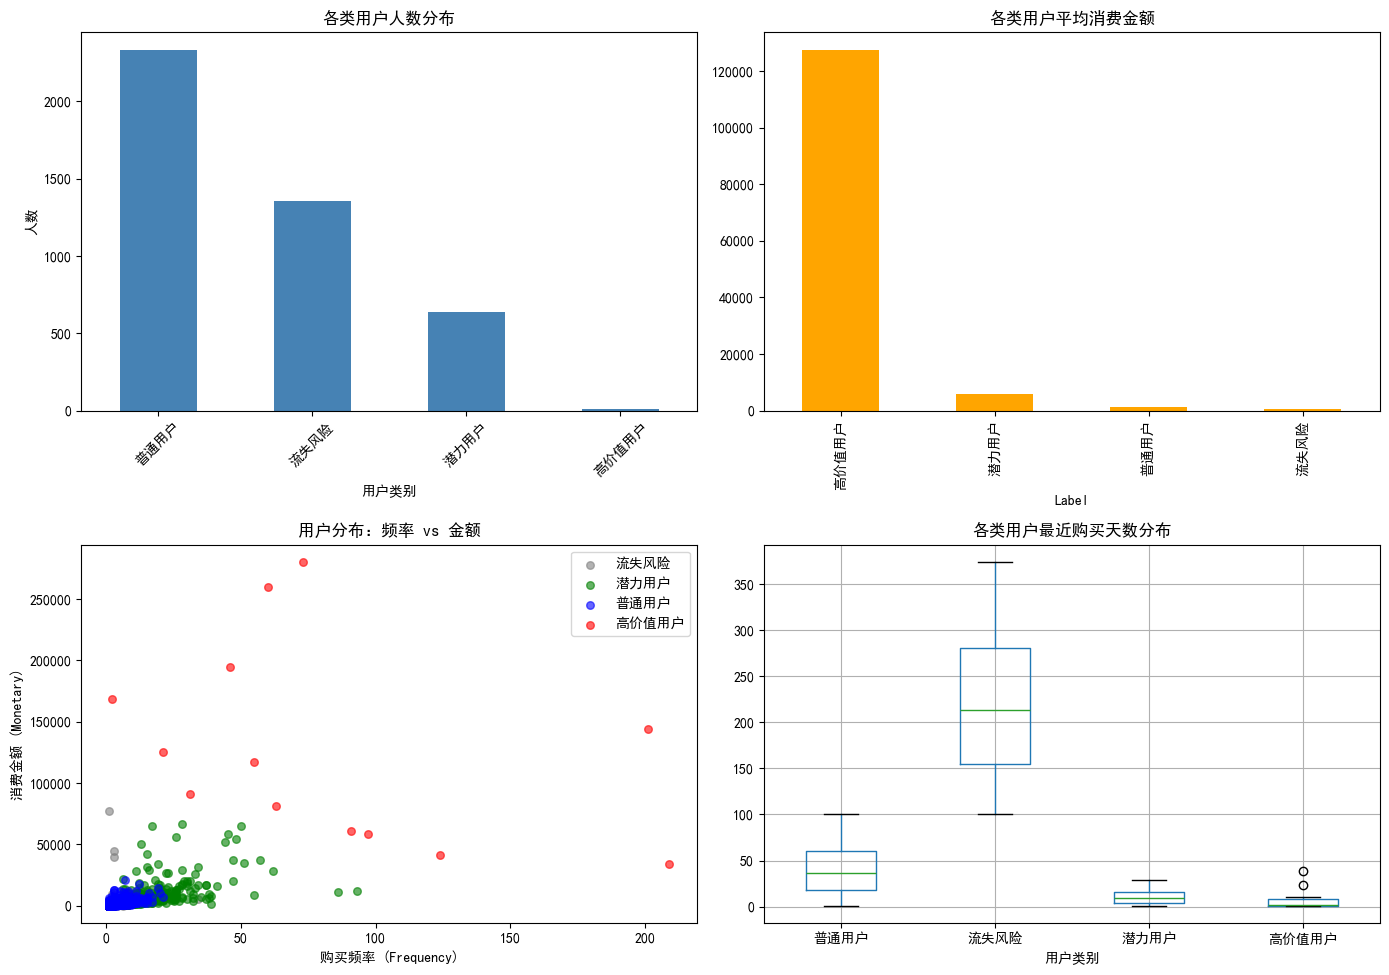

图表已保存到本地


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
rfm['Label'].value_counts().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('各类用户人数分布')
axes[0,0].set_xlabel('用户类别')
axes[0,0].set_ylabel('人数')
axes[0,0].tick_params(axis='x', rotation=45)
rfm.groupby('Label')['Monetary'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[0,1], color='orange')
axes[0,1].set_title('各类用户平均消费金额')
colors = {'高价值用户': 'red', '潜力用户': 'green', '普通用户': 'blue', '流失风险': 'gray'}
for label in rfm['Label'].unique():
    subset = rfm[rfm['Label'] == label]
    axes[1,0].scatter(subset['Frequency'], subset['Monetary'], 
                      c=colors.get(label, 'black'), label=label, alpha=0.6, s=30)
axes[1,0].set_xlabel('购买频率 (Frequency)')
axes[1,0].set_ylabel('消费金额 (Monetary)')
axes[1,0].set_title('用户分布：频率 vs 金额')
axes[1,0].legend()
rfm.boxplot(column='Recency', by='Label', ax=axes[1,1])
axes[1,1].set_title('各类用户最近购买天数分布')
axes[1,1].set_xlabel('用户类别')
plt.suptitle('')  # 去掉默认标题
plt.tight_layout()
plt.savefig(r'C:\Users\zp\Desktop\学习\电商分析项目\rfm_analysis.png', dpi=150)
plt.show()
print("图表已保存到本地")

In [20]:
rfm.to_excel(r'C:\Users\zp\Desktop\学习\电商分析项目\rfm_result.xlsx', index=False)
print("rfm_result.xlsx")

rfm_result.xlsx
